# Channel Detection 
## Preparations

In [1]:
import cv2
import pandas as pd
import numpy as np
from utils import (
    detection_metrics,
    display_colorimg,
    display_img,
    display_sbs,
    kaggle_submission,
    show_image_with_grayscale_channels
)
from skimage.filters import frangi


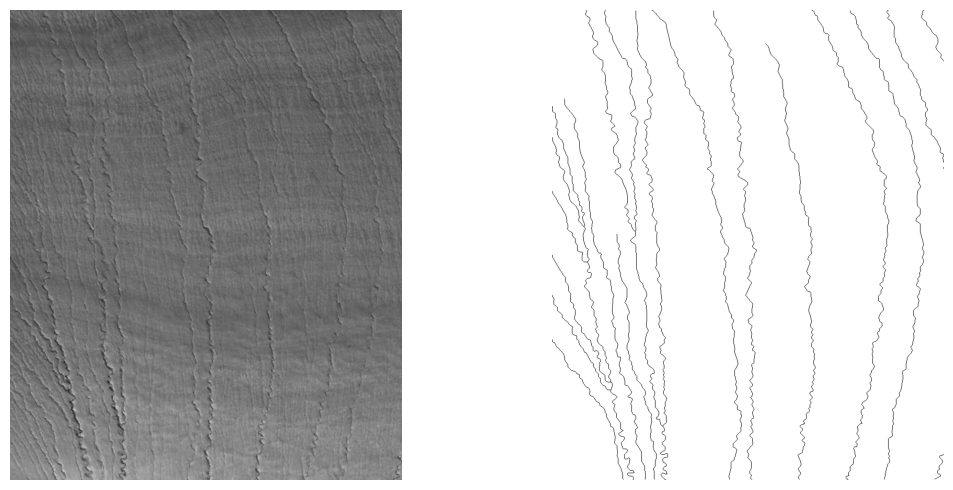

In [ ]:
glacier = cv2.imread('data/glacier.png', cv2.IMREAD_GRAYSCALE)
truth = cv2.imread('data/channels.png', cv2.IMREAD_GRAYSCALE)
display_sbs(glacier, truth)

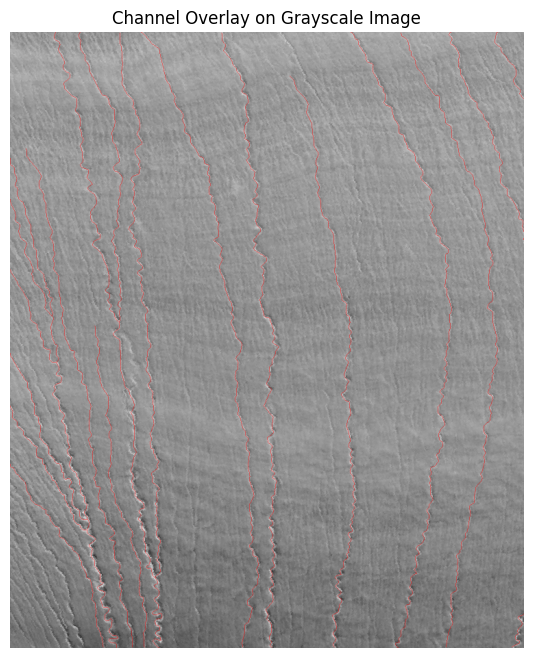

In [ ]:

show_image_with_grayscale_channels(glacier, truth)

In [4]:
print(glacier.shape)
print(glacier.min(), glacier.max())

(900, 750)
31 213


(array([2.0000e+00, 0.0000e+00, 3.0000e+00, 0.0000e+00, 0.0000e+00,
        4.0000e+00, 0.0000e+00, 4.0000e+00, 5.0000e+00, 2.0000e+00,
        0.0000e+00, 7.0000e+00, 7.0000e+00, 0.0000e+00, 8.0000e+00,
        1.7000e+01, 2.7000e+01, 0.0000e+00, 2.1000e+01, 2.3000e+01,
        0.0000e+00, 2.6000e+01, 3.0000e+01, 4.2000e+01, 0.0000e+00,
        4.2000e+01, 4.2000e+01, 0.0000e+00, 4.4000e+01, 5.8000e+01,
        6.1000e+01, 0.0000e+00, 5.7000e+01, 7.5000e+01, 0.0000e+00,
        9.1000e+01, 1.0700e+02, 1.1600e+02, 0.0000e+00, 1.3400e+02,
        1.6100e+02, 0.0000e+00, 1.5700e+02, 1.9900e+02, 0.0000e+00,
        2.0600e+02, 1.9500e+02, 2.7000e+02, 0.0000e+00, 2.4000e+02,
        2.8400e+02, 0.0000e+00, 3.3500e+02, 3.9100e+02, 4.1600e+02,
        0.0000e+00, 4.5200e+02, 4.8000e+02, 0.0000e+00, 4.9800e+02,
        7.1300e+02, 7.1400e+02, 0.0000e+00, 8.3200e+02, 1.0990e+03,
        0.0000e+00, 1.1390e+03, 1.3880e+03, 1.7190e+03, 0.0000e+00,
        2.0180e+03, 2.2750e+03, 0.0000e+00, 2.76

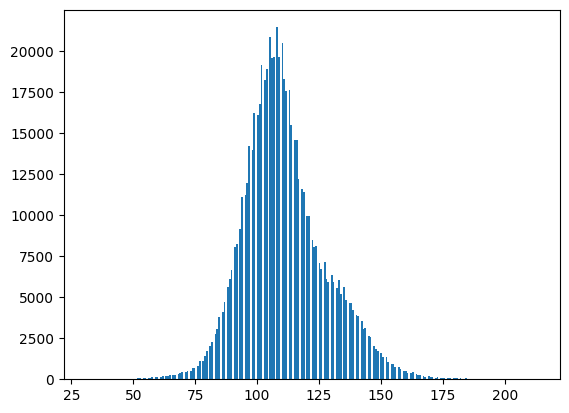

In [5]:
import matplotlib.pyplot as plt
plt.hist(glacier.ravel(), bins=256)

### BASELINE detection

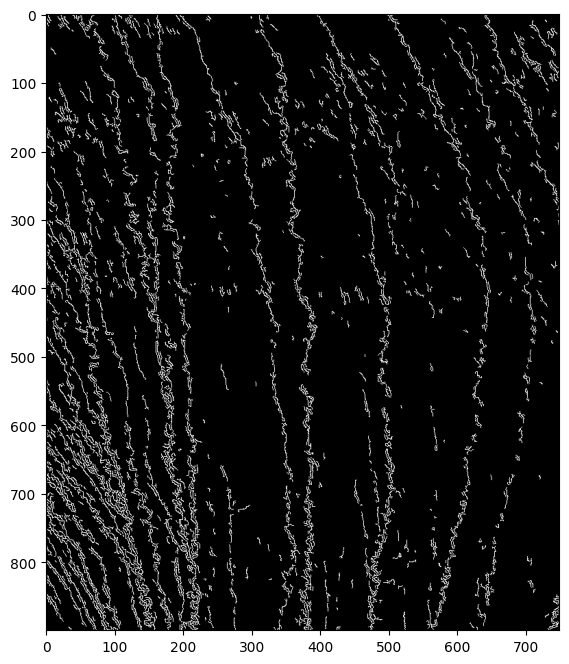

In [ ]:

canny = cv2.Canny(glacier, 75, 150)
display_img(canny)

  Metric    Value
f1_score 0.569954


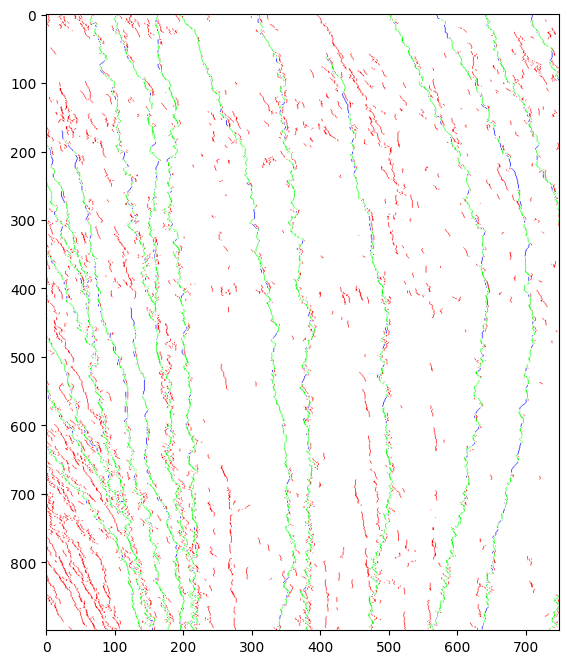

In [7]:
vis, metrics = detection_metrics(canny, truth)
df = pd.DataFrame(metrics.items(), columns=["Metric", "Value"])
print(df.to_string(index=False))
display_colorimg(vis)

### More sophisticated attempts

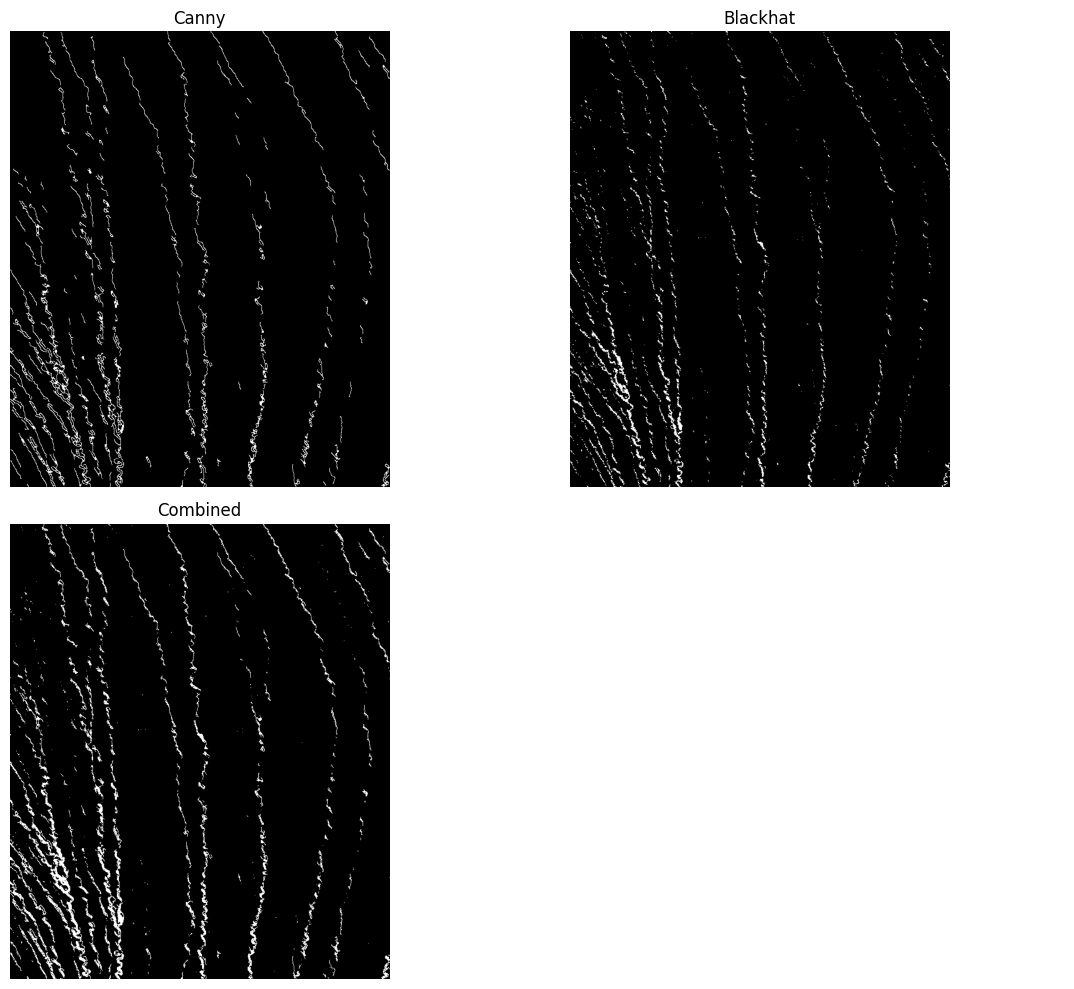

{'f1_score': np.float64(0.706141)}


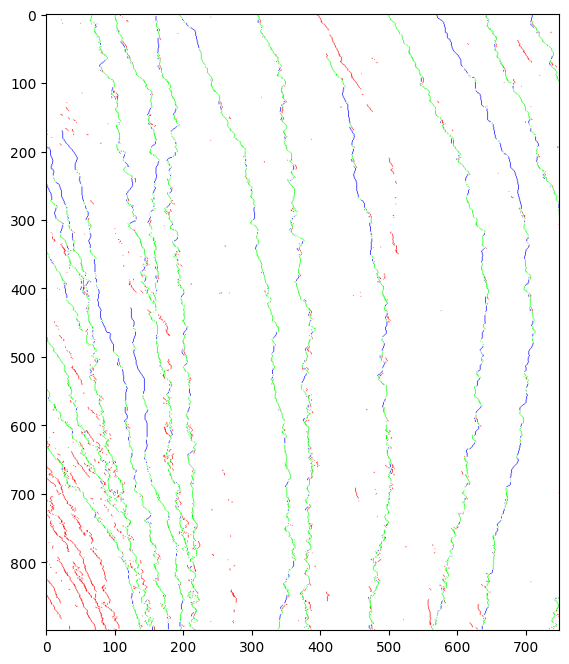

In [8]:
### your fancy attempts here :)
blur = cv2.GaussianBlur(glacier, (5,5),0)
canny = cv2.Canny(blur, 55, 125)
kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
canny_closed = cv2.morphologyEx(canny, cv2.MORPH_CLOSE, kernel_close)


kernel_bh = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (13, 13))
blackhat = cv2.morphologyEx(glacier, cv2.MORPH_BLACKHAT, kernel_bh)
blackhat_pred = (blackhat > 37).astype("uint8") * 255

combined = cv2.bitwise_or(canny_closed, blackhat_pred)

display_sbs(canny_closed, blackhat_pred, combined, titles=["Canny", "Blackhat", "Combined"])

vis, metrics = detection_metrics(combined, truth)
print(metrics)
display_colorimg(vis)

{'f1_score': np.float64(0.717941)}


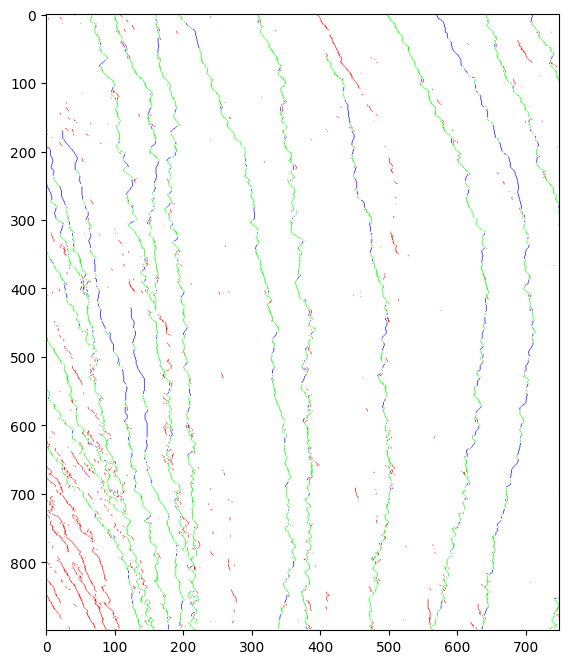

In [9]:
# Frangi
img = glacier.astype(np.float32) / 255.0
inv = 1 - img

fr = frangi(
    inv,
    sigmas=[2, 3, 4, 5],
    black_ridges=False
)

frangi_pred = (fr > 0.09).astype("uint8") * 255

# Final combined
final_pred = cv2.bitwise_or(combined, frangi_pred)

vis, metrics = detection_metrics(final_pred, truth)
print(metrics)
display_colorimg(vis)

FULL image

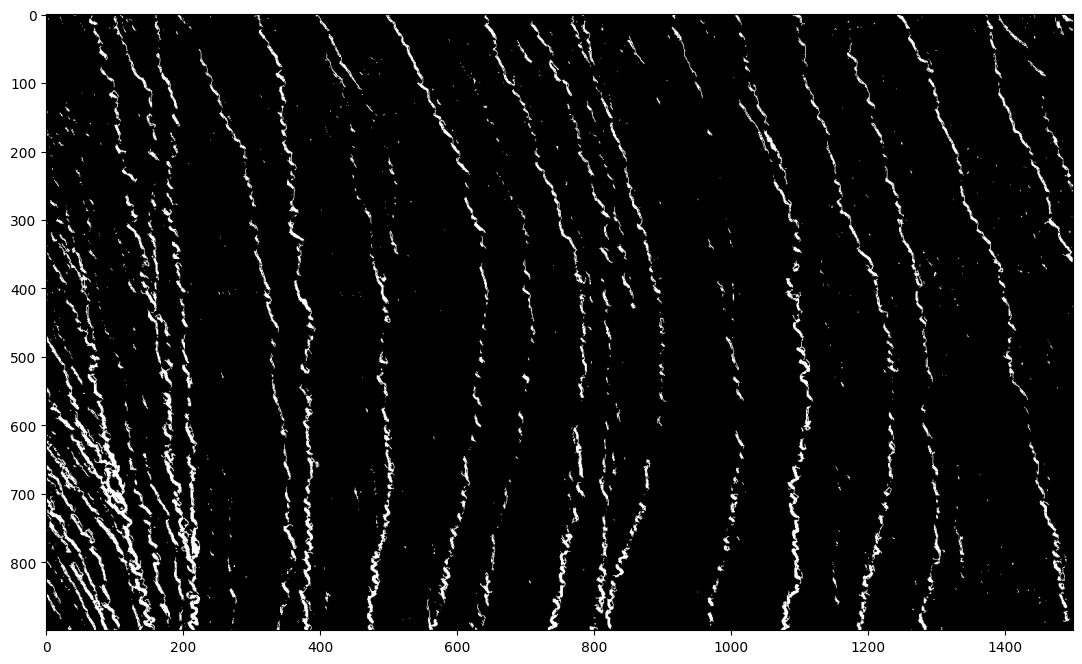

(900, 1500)


In [55]:
glacier_full = cv2.imread("data/glacier_FULL.png", cv2.IMREAD_GRAYSCALE)
# apply same methods as before (use a function if there are more steps)
blur_full = cv2.GaussianBlur(glacier_full, (5,5), 0)
canny_full = cv2.Canny(blur_full, 55, 125)
kernel_close = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (3,3)
)
canny_closed_full = cv2.morphologyEx(
    canny_full,
    cv2.MORPH_CLOSE,
    kernel_close
)


kernel_bh = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (13,13)
)
blackhat_full = cv2.morphologyEx(
    glacier_full,
    cv2.MORPH_BLACKHAT,
    kernel_bh
)
blackhat_pred_full = (
    blackhat_full > 35
).astype("uint8") * 255

img_full = glacier_full.astype(np.float32) / 255.0
inv_full = 1 - img_full

fr_full = frangi(
    inv_full,
    sigmas=[2, 3, 4, 5],
    black_ridges=False
)

frangi_pred_full = (
    fr_full > 0.09 
).astype("uint8") * 255

combined_temp = cv2.bitwise_or(
    canny_closed_full,
    blackhat_pred_full
)

final_full = cv2.bitwise_or(
    combined_temp,
    frangi_pred_full
)

# visualize
display_img(final_full)

print(final_full.shape)

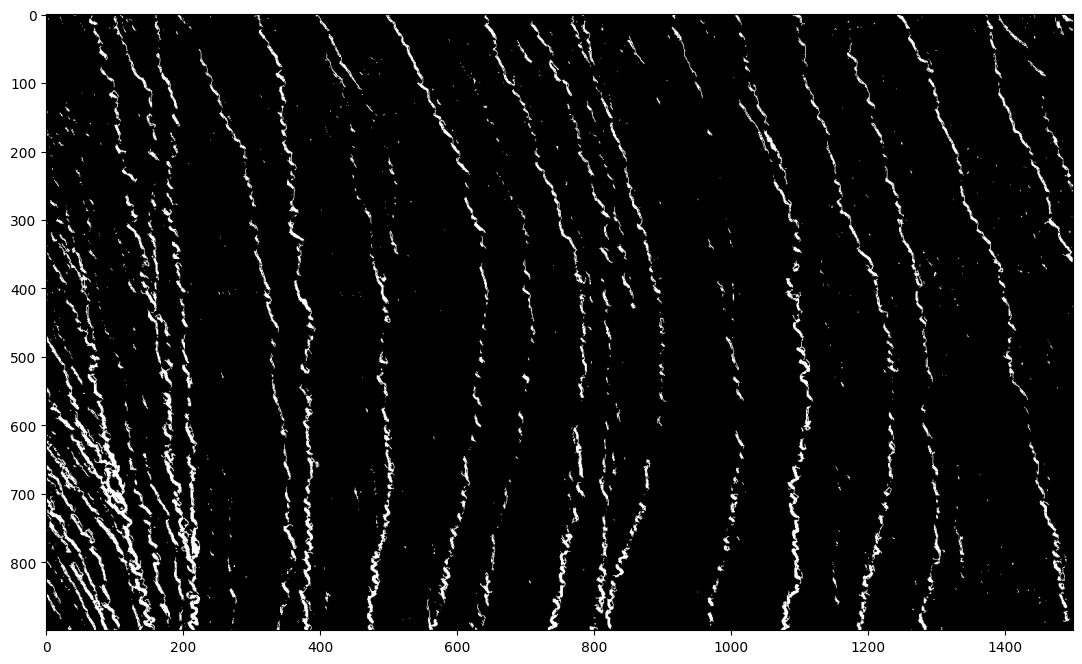

In [56]:
display_img(final_full)

In [57]:
# kaggle submission function adds an ID column named "row" to the results
# give your submissions meaningful names so you find them again 
kaggle_submission(final_full,"final_full_submission.csv")

,row,0,1,2,3,4,5,6,7,8,...,1490,1491,1492,1493,1494,1495,1496,1497,1498,1499
0,1,0,0,0,0,0,0,0,0,0,...,0,0,255,255,255,255,255,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,255,0,0,0,0,0
2,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,255,0,0,0,0,0,0,0,0,0
4,5,0,0,0,0,0,0,0,0,0,...,255,255,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,896,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
896,897,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
897,898,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
898,899,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
